### Notebook 01 — Bigram Language Model

#### Introdução

Neste notebook construiremos nosso primeiro modelo de linguagem.

Embora extremamente simples, ele contém várias das ideias fundamentais presentes em sistemas modernos de IA, incluindo os Large Language Models (LLMs).

O objetivo não é criar um modelo poderoso, mas compreender os princípios básicos que permitiram a evolução da área.

Ao longo desta trilha veremos a seguinte progressão:

**Bigrama** — contagens e probabilidades (este notebook)

→ **Neural Bigrama** — mesma ideia, mas os parâmetros são aprendidos por gradiente

→ **Markov** — contexto maior, não apenas um token atrás

→ **HMM** — estados ocultos, incerteza sobre o contexto

→ **Embeddings** — representações densas, significado começa a emergir

→ **Attention** — o modelo aprende a focar nas partes relevantes do contexto

→ **Transformers** — arquitetura completa dos modelos modernos

→ **LLMs** — escala, pré-treino, fine-tuning

Este notebook representa o primeiro passo dessa jornada.

---

#### O que vamos aprender

Ao final deste notebook você deverá entender:

- O que é um token e um vocabulário
- Como texto vira números
- Por que separamos dados de treino e teste
- O que são bigramas e probabilidades condicionais
- O que é um token especial de início de sequência
- Como um modelo gera texto autoregressivamente
- O que é perplexidade e por que ela importa
- Por que contexto limitado é um problema fundamental

---
### 1. Carregando o Dataset

#### Objetivo

Todo modelo de linguagem precisa aprender a partir de exemplos.

Esses exemplos compõem o **dataset**: o conjunto de textos usado durante o treinamento.

Neste primeiro notebook utilizaremos um dataset extremamente pequeno.

O objetivo não é construir um modelo poderoso, mas entender os conceitos fundamentais.

Mais adiante utilizaremos datasets maiores e mais realistas.

---

#### O que é um dataset?

Um dataset é o conjunto de informações utilizado para ensinar o modelo.

Exemplos:

- livros
- artigos
- diálogos
- código-fonte
- páginas da internet

Modelos modernos são treinados com bilhões ou até trilhões de tokens.

Nosso primeiro modelo será treinado com apenas algumas linhas de texto.

In [26]:
# ==================================================
# SEÇÃO 1 - CARREGAR DATASET
# ==================================================

with open("../../data/input.txt", "r", encoding="utf-8") as f:
    text = f.read().strip()

print(text)

ola mundo
o gato dormiu
o cachorro latiu
ola chatgpt


#### Exercício de Reflexão

Observe o conteúdo carregado.

Pergunta:

O modelo está enxergando palavras, frases ou apenas texto bruto?

Pense na resposta antes de continuar.

#### Conceito Importante

Neste momento ainda não existe tokenização.

O modelo possui apenas uma sequência de caracteres.

Para o computador, texto é apenas uma sequência de símbolos armazenados na memória.

---
### 2. Separando Treino e Teste

#### Objetivo

Antes de qualquer processamento, precisamos separar os dados em dois conjuntos:

- **Treino**: o modelo aprende os padrões a partir desses dados
- **Teste**: usado para avaliar se o modelo generalizou para dados que nunca viu

---

#### Por que separar?

Imagine que você decorou as respostas de uma prova.

Se a avaliação usar as mesmas perguntas, você vai bem.

Mas isso não prova que você aprendeu de verdade.

O mesmo vale para modelos:

Um modelo avaliado nos próprios dados de treino pode parecer excelente, mas falhar completamente com dados novos.

Esse fenômeno é chamado de **overfitting**.

---

#### Intuição

A divisão mais comum é:

- 80% dos dados para treino
- 20% dos dados para teste

Nosso dataset tem 4 linhas, então usaremos 3 para treino e 1 para teste.

In [27]:
# ==================================================
# SEÇÃO 2 - SPLIT TREINO / TESTE
# ==================================================

lines = text.split('\n')

split_idx = int(len(lines) * 0.75)

train_lines = lines[:split_idx]
test_lines  = lines[split_idx:]

train_text = '\n'.join(train_lines)
test_text  = '\n'.join(test_lines)

print(f"Total de linhas : {len(lines)}")
print(f"Treino          : {len(train_lines)} linhas")
print(f"Teste           : {len(test_lines)} linhas")
print()
print("--- Treino ---")
print(train_text)
print()
print("--- Teste ---")
print(test_text)

Total de linhas : 4
Treino          : 3 linhas
Teste           : 1 linhas

--- Treino ---
ola mundo
o gato dormiu
o cachorro latiu

--- Teste ---
ola chatgpt


#### Exercício de Reflexão

O modelo vai aprender apenas com o conjunto de treino.

Pergunta:

Se o texto de teste contiver caracteres que não aparecem no treino, o que acontece?

Como modelos modernos lidam com esse problema?

#### Conceito Importante

A separação treino/teste é um dos princípios fundamentais do aprendizado de máquina.

Sem ela, não temos como saber se o modelo aprendeu padrões genuínos ou simplesmente memorizou os dados.

Note que construiremos o vocabulário a partir do texto **completo** — treino e teste juntos.

Isso garante que todos os símbolos que possam aparecer no teste já estejam mapeados para um ID.

---
### 3. Criando o Vocabulário

#### Objetivo

Descobrir todos os símbolos únicos presentes no dataset e atribuir um ID numérico a cada um.

Esse conjunto de símbolos é chamado de **vocabulário**.

Todo modelo de linguagem possui algum tipo de vocabulário.

Sem ele, o modelo não consegue representar texto matematicamente.

---

#### O que é um vocabulário?

Vocabulário é o conjunto de tokens que o modelo conhece.

Neste notebook cada caractere será tratado como um token.

Exemplo:

Texto: `ola mundo`

Tokens únicos: `[' ', 'a', 'd', 'l', 'm', 'n', 'o', 'u']`

Cada token recebe um ID numérico — é com esses IDs que o modelo vai trabalhar.

---

#### Adicionando um token especial de início

Além dos caracteres do texto, adicionaremos um token especial: `^`

O motivo: o modelo de bigrama só sabe responder uma pergunta — "dado o token atual, qual vem depois?" Mas quando vamos **gerar** texto, surge um problema: qual é o primeiro token?

Sem um token de início, você precisaria fornecer o primeiro caractere manualmente, porque o modelo nunca aprendeu como sequências costumam começar.

Com o `^`, ensinamos isso durante o treino. O modelo observa transições como:

```
^ → o   (início de "ola mundo")
^ → o   (início de "o gato dormiu")
^ → o   (início de "o cachorro latiu")
```

No nosso dataset, toda sequência começa com `o` — então o modelo aprende que depois de `^` quase sempre vem `o`.

Na geração, você passa apenas `^` e o modelo decide sozinho qual é o primeiro caractere real.

---

#### Por que `^` e não outro símbolo?

Nenhuma razão especial — qualquer símbolo **ausente do dataset** funcionaria: `|`, `~`, `@`.

O que importa é não colidir com caracteres reais do texto. Se usássemos `o` como token de início, o modelo misturaria "estou no começo de uma sequência" com "acabei de ver a letra o".

---

#### Esse mesmo conceito em modelos modernos

- GPT usa `<|endoftext|>` — você passa esse token e o modelo gera o restante
- BERT usa `[CLS]` no início de cada entrada
- LLaMA e Mistral usam `<s>`

A ideia é sempre a mesma: um símbolo reservado que o modelo aprende a reconhecer como "aqui começa algo novo".

In [30]:
# ==================================================
# SEÇÃO 3 - VOCABULÁRIO
# ==================================================
#
# START é o token especial de início de sequência.
# Usamos '^' pois ele não aparece no dataset.
# Qualquer símbolo ausente do texto serviria.
#
# ==================================================

START = '^'

chars = [START] + sorted(list(set(text)))

vocab_size = len(chars)

print(chars)
print()
print(f"Vocabulary Size: {vocab_size}")

['^', '\n', ' ', 'a', 'c', 'd', 'g', 'h', 'i', 'l', 'm', 'n', 'o', 'p', 'r', 't', 'u']

Vocabulary Size: 17


#### Exercício de Reflexão

Observe que `^` aparece como primeiro elemento do vocabulário.

Pergunta:

Se adicionarmos um novo caractere ao dataset — por exemplo `@` — o tamanho do vocabulário aumenta ou permanece igual?

E se adicionarmos `^`? O que aconteceria?

#### Conceito Importante

O vocabulário define todos os símbolos que o modelo é capaz de representar.

Se um símbolo não estiver no vocabulário, o modelo não saberá como processá-lo.

Tokens especiais como `^` precisam ser reservados antes de qualquer processamento — por isso os adicionamos antes de construir o vocabulário a partir do texto.

---
### 4. Tokenização

#### Objetivo

Converter texto em números.

Modelos de linguagem não trabalham diretamente com texto.

Toda informação precisa ser representada numericamente antes de ser processada.

Esse processo é chamado de **tokenização**.

---

#### Exemplo Visual

Texto: `ola`

↓

Tokens: `['o', 'l', 'a']`

↓

IDs: `[12, 9, 3]`

(os IDs exatos dependem do vocabulário construído — execute a célula para ver os valores reais)

---

#### Por que converter texto para números?

Operações matemáticas são realizadas sobre números.

Como redes neurais trabalham com álgebra linear, precisamos transformar cada token em uma representação numérica.

---

#### encode e decode

Criamos duas funções:

- `encode`: texto → lista de IDs
- `decode`: lista de IDs → texto

Essas duas operações precisam ser inversas uma da outra.

In [31]:
# ==================================================
# SEÇÃO 4 - TOKENIZAÇÃO
# ==================================================

stoi = {ch: i for i, ch in enumerate(chars)}  # string → index
itos = {i: ch for i, ch in enumerate(chars)}  # index  → string

encode = lambda s:   [stoi[c] for c in s]
decode = lambda ids: ''.join([itos[i] for i in ids])

# --------------------------------------------------

word   = "ola"
tokens = list(word)
ids    = encode(word)
back   = decode(ids)

print(f"Texto  : {word}")
print(f"Tokens : {tokens}")
print(f"IDs    : {ids}")
print(f"Decode : {back}")

Texto  : ola
Tokens : ['o', 'l', 'a']
IDs    : [12, 9, 3]
Decode : ola


#### Exercício de Reflexão

Considere o texto: `gato`

Pergunta:

O modelo está armazenando a palavra "gato" ou apenas os IDs correspondentes aos caracteres?

O que acontece com o significado da palavra durante essa transformação?

#### Conceito Importante

Tokenização não significa compreensão.

O modelo apenas substitui símbolos por números.

O significado ainda não existe para a máquina — ele será construído nas próximas etapas, a partir das relações estatísticas observadas durante o treinamento.

---
### 5. Tokenizando Treino e Teste

#### Objetivo

Aplicar a tokenização aos dois conjuntos de dados.

Aqui também inserimos o token `^` no início de cada linha, conforme explicado na seção anterior.

---

#### Como fica na prática?

Cada linha do dataset é transformada assim:

```
"ola mundo"       →   "^ola mundo\n"
"o gato dormiu"   →   "^o gato dormiu\n"
"o cachorro latiu" →  "^o cachorro latiu\n"
```

O modelo vai aprender todas as transições presentes nessas sequências, incluindo `^ → o` em todas elas.

In [32]:
# ==================================================
# SEÇÃO 5 - TOKENIZANDO TREINO E TESTE
# ==================================================
#
# Cada linha vira: ^ + conteúdo + \n
#
# Exemplo: "ola mundo" → "^ola mundo\n"
#
# ==================================================

train_data = []

for line in train_lines:
    train_data += encode(START + line + '\n')

test_data = []

for line in test_lines:
    test_data += encode(START + line + '\n')

print("Treino (primeiros 20 tokens):")
print(train_data[:20])
print()
print("Decode dos primeiros 20 tokens:")
print(repr(decode(train_data[:20])))

Treino (primeiros 20 tokens):
[0, 12, 9, 3, 2, 10, 16, 11, 5, 12, 1, 0, 12, 2, 6, 3, 15, 12, 2, 5]

Decode dos primeiros 20 tokens:
'^ola mundo\n^o gato d'


#### Exercício de Reflexão

Observe o decode dos primeiros 20 tokens.

Você consegue ver onde uma linha termina e a próxima começa?

O token `^` aparece mais de uma vez. Por quê?

#### Conceito Importante

O `^` aparece no início de cada linha porque cada linha é uma sequência independente.

O modelo aprenderá que `^` sinaliza: "uma nova sequência está começando".

Durante a geração, usaremos exatamente esse sinal para iniciar.

---
### 6. Construindo os Bigramas

#### Objetivo

Extrair conhecimento do dataset de treino observando relações entre tokens consecutivos.

Essas relações são chamadas de **bigramas**.

---

#### O que é um Bigrama?

Um bigrama é um par formado por dois tokens consecutivos.

Exemplo:

Texto: `ola`

Tokens: `o → l → a`

Bigramas: `(o, l)` e `(l, a)`

---

#### O que o modelo está tentando descobrir?

A pergunta central é:

> "Dado o token atual, qual token costuma aparecer em seguida?"

Essa é uma das ideias fundamentais dos modelos de linguagem.

Mesmo modelos modernos como GPT continuam tentando prever o próximo token.

A diferença está na quantidade de contexto utilizada para fazer essa previsão.

In [33]:
# ==================================================
# SEÇÃO 6 - CONSTRUÇÃO DOS BIGRAMAS
# ==================================================
#
# Percorremos a sequência de treino e contamos
# quantas vezes cada transição (atual → próximo)
# ocorre.
#
# ==================================================

bigrams = {}

for i in range(len(train_data) - 1):

    current_token = train_data[i]
    next_token    = train_data[i + 1]

    if current_token not in bigrams:
        bigrams[current_token] = {}

    if next_token not in bigrams[current_token]:
        bigrams[current_token][next_token] = 0

    bigrams[current_token][next_token] += 1

In [34]:
# ==================================================
# VISUALIZANDO TRANSIÇÕES
# ==================================================

for current_token in sorted(bigrams.keys()):

    current_char = itos[current_token]

    print(f"\nDepois de {repr(current_char)}")

    for next_token, count in bigrams[current_token].items():

        next_char = itos[next_token]

        print(f"  -> {repr(next_char)} : {count}")


Depois de '^'
  -> 'o' : 3

Depois de '\n'
  -> '^' : 2

Depois de ' '
  -> 'm' : 1
  -> 'g' : 1
  -> 'd' : 1
  -> 'c' : 1
  -> 'l' : 1

Depois de 'a'
  -> ' ' : 1
  -> 't' : 2
  -> 'c' : 1

Depois de 'c'
  -> 'a' : 1
  -> 'h' : 1

Depois de 'd'
  -> 'o' : 2

Depois de 'g'
  -> 'a' : 1

Depois de 'h'
  -> 'o' : 1

Depois de 'i'
  -> 'u' : 2

Depois de 'l'
  -> 'a' : 2

Depois de 'm'
  -> 'u' : 1
  -> 'i' : 1

Depois de 'n'
  -> 'd' : 1

Depois de 'o'
  -> 'l' : 1
  -> '\n' : 1
  -> ' ' : 4
  -> 'r' : 2

Depois de 'r'
  -> 'm' : 1
  -> 'r' : 1
  -> 'o' : 1

Depois de 't'
  -> 'o' : 1
  -> 'i' : 1

Depois de 'u'
  -> 'n' : 1
  -> '\n' : 2


#### Exercício de Reflexão

Observe as transições encontradas.

Perguntas:

- Quais caracteres aparecem depois de `'^'`?
- O que isso diz sobre como as frases do dataset costumam começar?
- Se adicionarmos uma frase que começa com `a`, o que muda nas transições de `'^'`?

#### Conceito Importante

Neste momento o modelo ainda não entende significado.

Ele não sabe o que é cachorro, gato, dormir ou correr.

Ele apenas observa padrões estatísticos: quais símbolos costumam aparecer após outros.

Esse é o limite do bigrama — e também o ponto de partida de toda a área.

---
### 7. Visualizando a Matriz de Bigramas

#### Objetivo

As contagens de bigramas formam uma **matriz**.

Cada linha representa um token atual.

Cada coluna representa um possível próximo token.

O valor em cada célula é a frequência observada no treino.

---

#### Por que visualizar?

Dois padrões ficam imediatamente visíveis:

1. A maioria das células é zero — a maioria das transições nunca ocorreu no treino
2. Algumas transições são muito mais frequentes que outras

---

#### Conexão com o futuro

Guarde essa imagem na memória.

Quando estudarmos **Attention**, veremos mapas de atenção com estrutura muito similar:

uma matriz que indica o quanto cada token "presta atenção" a cada outro token.

A intuição visual é a mesma — o que muda é o que os valores representam.

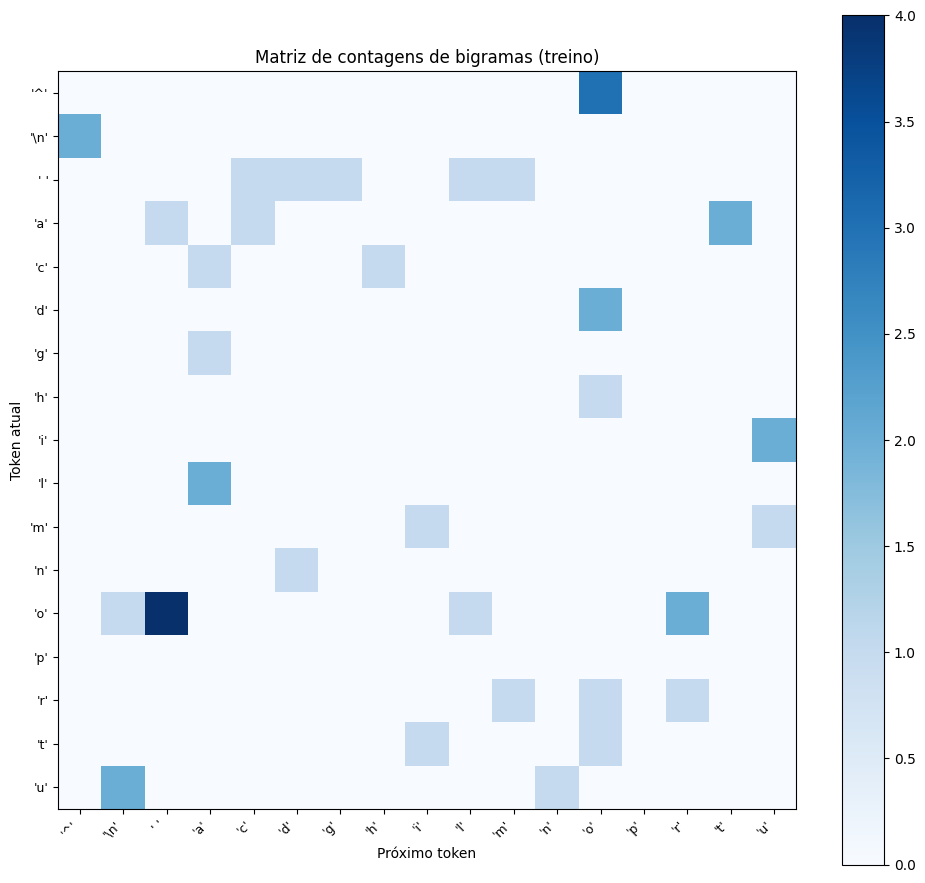

In [35]:
# ==================================================
# SEÇÃO 7 - HEATMAP DA MATRIZ DE BIGRAMAS
# ==================================================

import matplotlib.pyplot as plt

matrix = [[0] * vocab_size for _ in range(vocab_size)]

for current_token, transitions in bigrams.items():
    for next_token, count in transitions.items():
        matrix[current_token][next_token] = count

labels = [repr(itos[i]) for i in range(vocab_size)]

fig, ax = plt.subplots(figsize=(10, 9))

im = ax.imshow(matrix, cmap='Blues')

ax.set_xticks(range(vocab_size))
ax.set_yticks(range(vocab_size))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(labels, fontsize=9)

ax.set_xlabel('Próximo token')
ax.set_ylabel('Token atual')
ax.set_title('Matriz de contagens de bigramas (treino)')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

#### Exercício de Reflexão

Observe o heatmap.

Perguntas:

- Quais células estão mais escuras?
- O que uma linha completamente branca significa?
- O que uma linha com apenas uma célula escura significa?

Pense no que essas linhas dizem sobre as limitações do modelo.

#### Conceito Importante

A matriz de bigramas é **esparsa**: a maior parte das transições nunca ocorreu no treino.

Isso é uma limitação direta do tamanho do dataset.

Se um par (token_atual → token_seguinte) não foi visto no treino, o modelo atribui probabilidade zero a ele.

Isso causa problemas quando avaliamos o modelo em dados novos — veremos esse efeito quando calcularmos a perplexidade.

---
### 8. Transformando Contagens em Probabilidades

#### Objetivo

Até agora o modelo acumulou frequências: quantas vezes cada transição ocorreu.

Frequências sozinhas não são suficientes para fazer previsões.

Precisamos saber: dentre todas as vezes que o token `x` apareceu, com que proporção ele foi seguido por cada possível próximo token?

Essa proporção é a **probabilidade condicional**.

---

#### Intuição

Exemplo:

Depois do token `o` observamos:

- `l` → 2 vezes
- ` ` → 4 vezes
- `r` → 2 vezes
- `\n` → 1 vez

Total: 9 ocorrências

Probabilidades:

- `P(l | o)` = 2/9 ≈ 0.222
- `P(' ' | o)` = 4/9 ≈ 0.444
- `P(r | o)` = 2/9 ≈ 0.222
- `P('\n' | o)` = 1/9 ≈ 0.111

A soma deve ser sempre 1.0 — estamos distribuindo 100% da probabilidade entre todas as opções.

---

#### Normalização

O processo de converter contagens em probabilidades é chamado de **normalização**.

Cada linha da matriz de bigramas é dividida pelo total de sua linha.

In [36]:
# ==================================================
# SEÇÃO 8 - PROBABILIDADES
# ==================================================

probabilities = {}

for current_token, transitions in bigrams.items():

    total = sum(transitions.values())

    probabilities[current_token] = {}

    for next_token, count in transitions.items():

        probabilities[current_token][next_token] = (
            count / total
        )

In [37]:
# ==================================================
# VISUALIZANDO PROBABILIDADES
# ==================================================

for current_token in sorted(probabilities.keys()):

    current_char = itos[current_token]

    print(f"\nDepois de {repr(current_char)}")

    for next_token, prob in probabilities[current_token].items():

        next_char = itos[next_token]

        print(f"  -> {repr(next_char)} : {prob:.3f}")


Depois de '^'
  -> 'o' : 1.000

Depois de '\n'
  -> '^' : 1.000

Depois de ' '
  -> 'm' : 0.200
  -> 'g' : 0.200
  -> 'd' : 0.200
  -> 'c' : 0.200
  -> 'l' : 0.200

Depois de 'a'
  -> ' ' : 0.250
  -> 't' : 0.500
  -> 'c' : 0.250

Depois de 'c'
  -> 'a' : 0.500
  -> 'h' : 0.500

Depois de 'd'
  -> 'o' : 1.000

Depois de 'g'
  -> 'a' : 1.000

Depois de 'h'
  -> 'o' : 1.000

Depois de 'i'
  -> 'u' : 1.000

Depois de 'l'
  -> 'a' : 1.000

Depois de 'm'
  -> 'u' : 0.500
  -> 'i' : 0.500

Depois de 'n'
  -> 'd' : 1.000

Depois de 'o'
  -> 'l' : 0.125
  -> '\n' : 0.125
  -> ' ' : 0.500
  -> 'r' : 0.250

Depois de 'r'
  -> 'm' : 0.333
  -> 'r' : 0.333
  -> 'o' : 0.333

Depois de 't'
  -> 'o' : 0.500
  -> 'i' : 0.500

Depois de 'u'
  -> 'n' : 0.333
  -> '\n' : 0.667


#### Exercício de Reflexão

Observe as probabilidades associadas ao token `'^'`.

Perguntas:

- Quantas opções existem depois de `'^'`?
- As probabilidades somam 1.0?
- O que aconteceria se adicionarmos uma frase que começa com `a`?

#### Conceito Importante

Probabilidade não é certeza.

Uma probabilidade de 80% significa que aquele token aparece frequentemente — não sempre.

Modelos modernos não escolhem necessariamente o token mais provável a cada passo.

Eles realizam **amostragem probabilística**: o token mais provável é mais frequentemente escolhido, mas outros tokens também têm chance.

Isso é o que permite ao modelo gerar textos variados em vez de sempre repetir a mesma sequência.

---
### 9. A Matemática por Trás do Bigrama

#### Objetivo

Formalizar matematicamente o que acabamos de construir.

Nosso modelo responde sempre à mesma pergunta:

> Dado o token atual, qual é a probabilidade do próximo token?

Essa relação é chamada de **probabilidade condicional**.

---

#### Fórmula

$$
P(x_t \mid x_{t-1})
$$

Onde:

- $x_{t-1}$ é o token anterior (contexto)
- $x_t$ é o token que queremos prever

Lemos como: *probabilidade de $x_t$ dado que observamos $x_{t-1}$*.

---

#### Conectando com o que já vimos

Nas seções anteriores observamos transições como:

```
^ → o   (início de "ola mundo")
^ → o   (início de "o gato dormiu")
l → a   (em "ola")
```

Em notação formal, isso é:

$$
P(\texttt{o} \mid \texttt{\char`^}) = 1.0
\qquad
P(\texttt{a} \mid \texttt{l}) = 1.0
$$

E para um token com múltiplos sucessores possíveis, como `o`:

```
o → l   (2 vezes)
o → ' ' (4 vezes)
o → r   (2 vezes)
o → \n  (1 vez)
```

$$
P(\texttt{l} \mid \texttt{o}) = 0.222
\qquad
P(\texttt{' '} \mid \texttt{o}) = 0.444
\qquad
P(\texttt{r} \mid \texttt{o}) = 0.222
$$

A fórmula é apenas a forma compacta de escrever o que as contagens já expressam.

---

#### A limitação fundamental

Nosso modelo usa apenas um token de contexto:

$$
P(x_t \mid x_{t-1})
$$

Um modelo ideal usaria todo o histórico:

$$
P(x_t \mid x_{t-1}, x_{t-2}, \ldots, x_1)
$$

A evolução dos modelos de linguagem é, em grande parte, a história de como aumentar esse contexto de forma eficiente.

#### Exercício de Reflexão

Considere as frases:

"O cachorro latiu."

"O cachorro correu."

Após o caractere `o` de "cachorro", o modelo precisa decidir o próximo caractere.

Mas ele só enxerga `o` — não sabe que está dentro da palavra "cachorro".

Que informação ele está descartando? E qual seria o impacto disso na qualidade das previsões?

#### Conceito Importante

A principal limitação do modelo de bigramas é sua memória extremamente curta.

Ele só consegue enxergar o token imediatamente anterior.

Todo o restante do contexto é descartado.

Essa limitação será uma das principais motivações para o surgimento dos próximos modelos que estudaremos.

---
### 10. Gerando Texto

#### Objetivo

Utilizar o modelo para gerar texto novo.

A geração começa pelo token `^`, que o modelo aprendeu a usar como ponto de partida.

---

#### Como a geração funciona?

1. Começamos com `^`
2. Consultamos as probabilidades associadas a ele
3. Sorteamos o próximo token proporcionalmente às probabilidades
4. O token escolhido torna-se o novo token atual
5. Repetimos até encontrar `\n` ou atingir o limite de tokens

Essa estratégia é chamada de **geração autoregressiva**.

---

#### O que é autoregressivo?

Significa que cada nova previsão depende das previsões anteriores.

O modelo gera um token por vez e usa esse token para gerar o próximo.

Esse mesmo princípio está presente nos LLMs modernos — a diferença é que eles consideram muito mais contexto em cada passo.

In [55]:
# ==================================================
# SEÇÃO 10 - GERAÇÃO DE TEXTO
# ==================================================

import random

random.seed(42)

def generate(max_tokens=100):

    current_token = stoi[START]
    generated = []

    for _ in range(max_tokens):

        if current_token not in probabilities:
            break

        next_tokens = list(probabilities[current_token].keys())
        probs       = list(probabilities[current_token].values())

        next_token = random.choices(next_tokens, weights=probs, k=1)[0]

        char = itos[next_token]

        if char == '\n':
            break

        generated.append(char)
        current_token = next_token

    return ''.join(generated)


print("Gerando 5 sequências:\n")

for i in range(5):
    print(f"  {i+1}: {generate()}")

Gerando 5 sequências:

  1: ola chola ga miundolato
  2: o mu
  3: oro latiu
  4: o mundolato gacho
  5: o


#### Exercício de Reflexão

O `random.seed(42)` está definido **fora** da função `generate`.

Isso significa que ele é executado uma vez ao rodar a célula inteira — o estado aleatório começa sempre do mesmo ponto, então as 5 sequências geradas são sempre as mesmas entre execuções.

Experimente remover o `random.seed(42)` e executar a célula várias vezes.

Perguntas:

- As sequências mudam entre execuções da célula?
- Por que fixar uma seed é útil durante o desenvolvimento?
- Em que situações você *não* quer fixar a seed?

#### Conceito Importante

`random.seed` fixa o estado interno do gerador de números aleatórios.

Com a seed definida, toda execução da célula produz exatamente o mesmo resultado — o que é chamado de **reprodutibilidade**.

Isso é essencial durante o desenvolvimento: se o modelo produz resultados diferentes a cada execução, fica impossível saber se uma mudança no código melhorou ou piorou o comportamento.

Em produção, a seed não deve ser fixada. Um chatbot que fixasse a seed responderia exatamente a mesma coisa para a mesma pergunta toda vez — perdendo a variabilidade que torna as respostas naturais.

---
### 11. Avaliando o Modelo — Perplexidade

#### Objetivo

Até agora avaliamos o modelo visualmente: "o texto gerado parece razoável?"

Isso não é suficiente para comparar modelos de forma objetiva.

Precisamos de uma **métrica numérica**.

A métrica padrão em modelos de linguagem é a **perplexidade**.

---

#### Intuição

Perplexidade mede o quanto o modelo ficou "surpreso" com os dados de teste.

- **Baixa perplexidade**: o modelo previu bem. Pouca surpresa.
- **Alta perplexidade**: o modelo errou muito. Muita surpresa.

Dois casos extremos:

- Um modelo perfeito que atribui probabilidade 1.0 ao token correto em cada passo tem perplexidade **1**.
- Um modelo que chuta aleatoriamente entre V tokens tem perplexidade **V** (o tamanho do vocabulário).

Quanto menor a perplexidade, melhor o modelo.

---

#### Fórmula

$$
PP = \exp\left(-\frac{1}{N} \sum_{t=1}^{N} \log P(x_t \mid x_{t-1})\right)
$$

Onde:

- $N$ é o número de tokens avaliados
- $P(x_t \mid x_{t-1})$ é a probabilidade que o modelo atribuiu ao token correto

---

#### Problema: bigramas com probabilidade zero

Se o modelo nunca viu um bigrama durante o treino, ele atribui probabilidade 0.

O log(0) é menos infinito — a fórmula quebra.

A solução mais simples é a **suavização de Laplace**: adicionamos uma constante pequena (`alpha`) a todas as contagens.

Isso garante que nenhum bigrama tenha probabilidade zero, mesmo que nunca tenha sido visto.

É uma técnica simples com uma intuição clara: "mesmo o que nunca vi tem alguma chance de acontecer".

In [58]:
# ==================================================
# SEÇÃO 11 - PERPLEXIDADE
# ==================================================

import math

# Suavização de Laplace: somamos alpha a todas as contagens.
# alpha=1 é o caso mais comum (suavização add-one).
alpha = 1

smooth_probs = {}

for current_token in range(vocab_size):

    counts = bigrams.get(current_token, {})
    total  = sum(counts.values()) + alpha * vocab_size

    smooth_probs[current_token] = {}

    for next_token in range(vocab_size):
        count = counts.get(next_token, 0)
        smooth_probs[current_token][next_token] = (
            (count + alpha) / total
        )


def perplexity(data, probs):

    log_sum = 0.0
    n = 0

    for i in range(len(data) - 1):
        current_token = data[i]
        next_token    = data[i + 1]
        p = probs[current_token][next_token]
        log_sum += math.log(p)
        n += 1

    return math.exp(-log_sum / n)


pp_train = perplexity(train_data, smooth_probs)
pp_test  = perplexity(test_data,  smooth_probs)

print(f"Perplexidade no treino : {pp_train:.2f}")
print(f"Perplexidade no teste  : {pp_test:.2f}")
print()
print(f"Referência — chute aleatório: {vocab_size}")

Perplexidade no treino : 7.93
Perplexidade no teste  : 11.62

Referência — chute aleatório: 17


#### Exercício de Reflexão

Observe os dois valores.

Perguntas:

- A perplexidade no treino é menor ou maior do que no teste?
- O que essa diferença indica sobre o comportamento do modelo?
- Tente `alpha=0` e observe o que acontece. Por quê?
- Tente `alpha=10`. Como isso afeta a diferença entre treino e teste?

#### Conceito Importante

Perplexidade no treino menor do que no teste é o sinal clássico de **overfitting**.

O modelo se ajustou bem ao que viu, mas generaliza mal para o que não viu.

Com apenas 4 linhas de dataset, esse efeito é exagerado e esperado.

Em modelos reais, a diferença entre perplexidade de treino e de teste é um dos principais sinais monitorados durante o treinamento.

A suavização de Laplace reduz o overfitting de forma modesta — ela redistribui um pouco de probabilidade para eventos não vistos.

Nos próximos notebooks veremos abordagens mais poderosas para esse problema.

---
### 12. O Nascimento de um Modelo de Linguagem

Parabéns.

Você acabou de construir um modelo de linguagem funcional do zero.

Ele é extremamente simples, mas já contém elementos fundamentais presentes em sistemas modernos:

| Conceito | Onde aparece nos LLMs modernos |
|---|---|
| Tokenização | Todos os modelos convertem texto em IDs |
| Token especial de início | `<s>`, `[CLS]`, `<|endoftext|>` |
| Split treino/teste | Presente em todo pipeline de ML |
| Probabilidade condicional | Base matemática de todos os LMs |
| Geração autoregressiva | GPT, LLaMA e outros geram um token por vez |
| Perplexidade | Métrica padrão para avaliar modelos de linguagem |

---

#### O que ele ainda não possui?

A principal limitação é a **memória**.

O modelo enxerga apenas um token anterior:

$$
P(x_t \mid x_{t-1})
$$

Todo o restante do contexto é descartado.

---

#### O que vem a seguir?

No próximo notebook manteremos a mesma estrutura — um bigrama que olha apenas um token atrás — mas substituiremos a tabela de contagens por uma **rede neural**.

Os parâmetros do modelo deixarão de ser calculados diretamente e passarão a ser aprendidos por **gradiente descendente**.

Essa mudança parece incremental, mas abre a porta para tudo que vem depois.

---
### Resumo

Neste notebook aprendemos:

✅ O que é um token e um vocabulário

✅ Como texto vira números (tokenização)

✅ Por que separamos treino e teste

✅ O que é um token especial e por que ele existe

✅ Como construir bigramas e visualizá-los como matriz

✅ O que é probabilidade condicional e como calculá-la

✅ Como gerar texto autoregressivamente

✅ O que é perplexidade e como interpretá-la

✅ O que é overfitting e como a suavização de Laplace o atenua

---

Próximo: **02 — Neural Bigrama**

#### Desafio Opcional

Experimente:

- Adicionar mais frases ao dataset e observar como a perplexidade muda
- Testar `alpha=0` na suavização e entender por que quebra
- Testar valores altos de `alpha` (10, 100) e observar o efeito
- Trocar o símbolo `^` por outro e confirmar que o comportamento não muda
- Adicionar `^` ao próprio dataset e observar o que acontece com o vocabulário